In [13]:
from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf

from starred.psf.psf import PSF, load_PSF_model
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction
from starred.procedures import build_psf

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [15]:
import jax
print(jax.devices())

[CpuDevice(id=0)]


In [90]:
from SFstarred.DataStarred import DataStarred
from SFstarred.utils import save_npy,correct_cutout_and_noise,mask_surrounding_stars
from SFstarred.stars_cut import normalize_data_error,normalize_data_error_photutils
from SFstarred.plots import twoplot,plot_star_mask,plot_stars_features,nice_psf_plot
from SFstarred.utils import build_psf_edit

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# !pwd

## Overview

This notebook starts from the results obtained in Chapter 1 and describes the steps used to derive the final PSF using the best-performing method from `PSF_starred_v10`.

(144,)
Single-cutout sky diagnostics
-----------------------------
sky_level              = 0.02368 e-
sigma_sky              = 0.007533 e-
mean corner residual   = 0.002425 e-
median corner residual = 0 e-
std corner residual    = 0.01163 e-
median corner noise    = 0.0309 e-
std / sigma_sky        = 1.544
z mean / median / std  = 0.062, -0.000, 0.334
valid corner pixels    = 144
- Empirical corner RMS and robust sky RMS differ significantly.
- Normalized corner residuals are not close to unit width.


/Users/felavila/Work/MyPackages/SFstarred/SFstarred/plots.py:713: RuntimeWarning: invalid value encountered in log10
  log_sn_map = np.log10(data / noise_map)


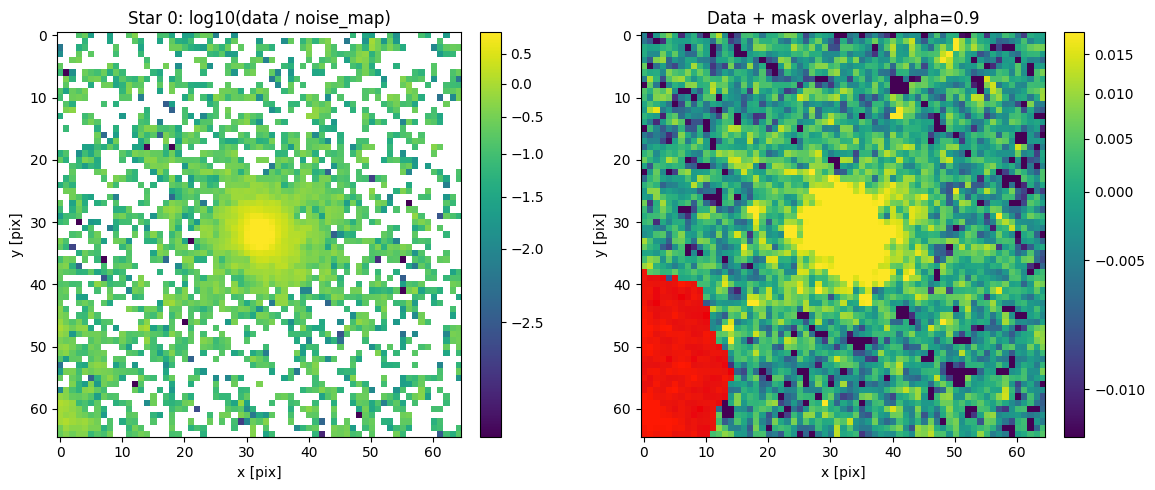

(144,)
Single-cutout sky diagnostics
-----------------------------
sky_level              = 0.0008847 e-
sigma_sky              = 0.0001939 e-
mean corner residual   = 1.55e-05 e-
median corner residual = -5.421e-20 e-
std corner residual    = 0.0001966 e-
median corner noise    = 0.001199 e-
std / sigma_sky        = 1.014
z mean / median / std  = 0.013, -0.000, 0.161
valid corner pixels    = 144
- Normalized corner residuals are not close to unit width.


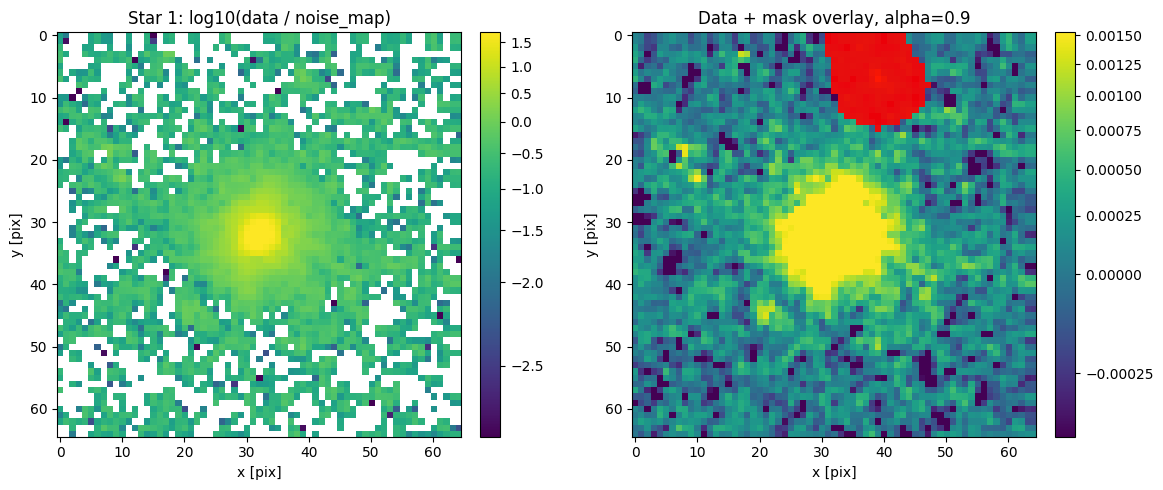

(144,)
Single-cutout sky diagnostics
-----------------------------
sky_level              = 0.005871 e-
sigma_sky              = 0.002065 e-
mean corner residual   = 7.617e-05 e-
median corner residual = 4.337e-19 e-
std corner residual    = 0.001666 e-
median corner noise    = 0.008372 e-
std / sigma_sky        = 0.807
z mean / median / std  = 0.007, -0.000, 0.196
valid corner pixels    = 144
- Normalized corner residuals are not close to unit width.


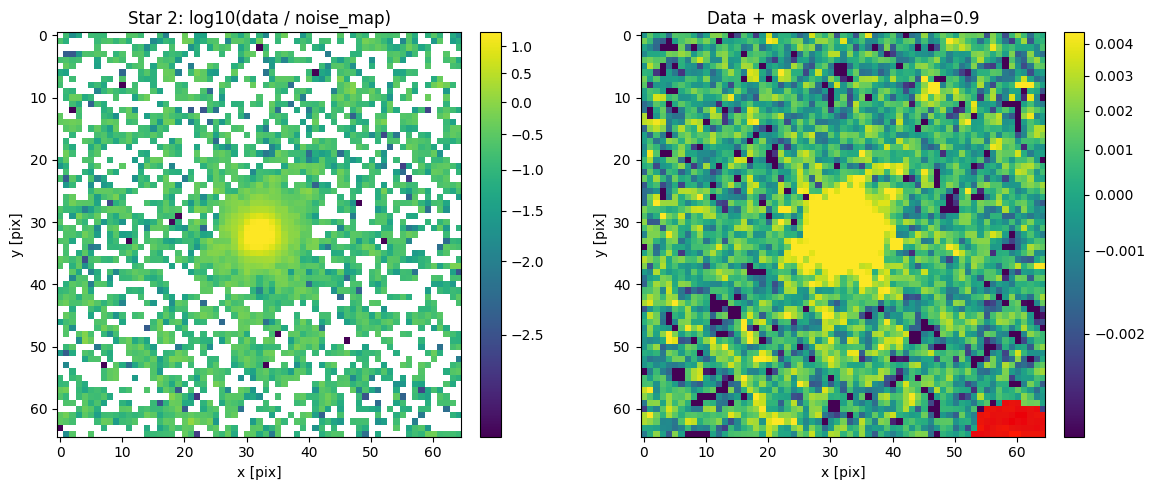

(144,)
Single-cutout sky diagnostics
-----------------------------
sky_level              = 0.005377 e-
sigma_sky              = 0.001544 e-
mean corner residual   = 0.0002174 e-
median corner residual = 4.337e-19 e-
std corner residual    = 0.001402 e-
median corner noise    = 0.007395 e-
std / sigma_sky        = 0.908
z mean / median / std  = 0.029, 0.000, 0.189
valid corner pixels    = 144
- Normalized corner residuals are not close to unit width.


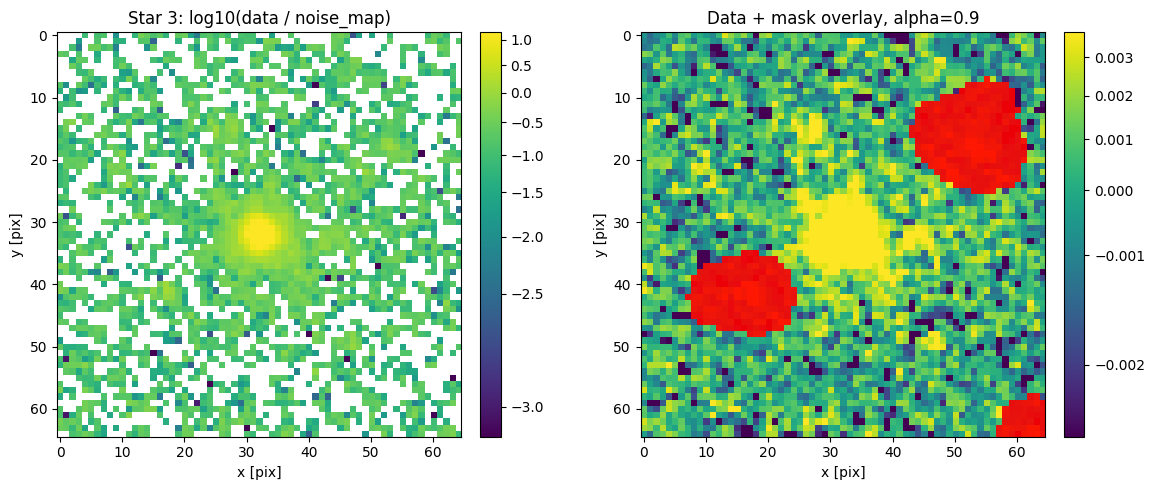

In [ ]:
#noise global for this case
data_f160W = pd.read_pickle("data_for_starred/data_for_starred.pickle")

stars_data = data_f160W["stars_data"]
stars_sigma_2= data_f160W['stars_sigma2']
exptime_seconds = data_f160W["exptime_seconds"]

stars = []
noise_maps = []
masks = []
n_total =  []
added_index= []
for n,i in enumerate(zip(stars_data,stars_sigma_2)):
    if n  in []: #stars 2 to 9 are very faint and have bad centering, we exclude them for the psf reconstruction
         continue
    #print(f"Processing star {n}...")
    data,sigma = i
    image_size = data.shape[0]
    #data, noise_map = data,np.sqrt(sigma)
    data, noise_map = normalize_data_error(data,np.sqrt(sigma),exptime_seconds=exptime_seconds)
    mas0 = (noise_map <= 0)
    
    data = np.where(mas0,0,data)
    noise_map = np.where(mas0,1e7,noise_map)
    #data, noise_map,*_ = normalize_data_error(data,sigma,exptime_seconds,None,corner=0.1)
    #if n==1:
     #   _mask,n_sources_masked = mask_surrounding_stars(data, noise_map,manual_masks=[[15,11,2],[15,18,2]],)
    #elif n==2:
     #   _mask,n_sources_masked = mask_surrounding_stars(data, noise_map,manual_masks=[[22,8,5],[15,11,2],[15,18,2]],)
    #elif n==3:
     #   _mask,n_sources_masked = mask_surrounding_stars(data, noise_map,manual_masks=[[17,4,3],[15,11,2],[15,18,2]],)
    #else:
    _mask,n_sources_masked = mask_surrounding_stars(data, noise_map,thresh=0.4,minarea=2,dilation_radius=5,deblend_cont=0.005,)
    mask = np.array(~mas0 & _mask).astype(float) 
    stars.append(data)
    noise_maps.append(noise_map)
    masks.append(mask)
    n_total.append(n_sources_masked)
    added_index.append(n)
    plot_star_mask(data,noise_map,mask,n=n,alpha_mask=0.9)
stars_data = np.array(stars)
noise_maps = np.array(noise_maps)
masks = np.array(masks)
stars_sigma_2 = noise_maps**2


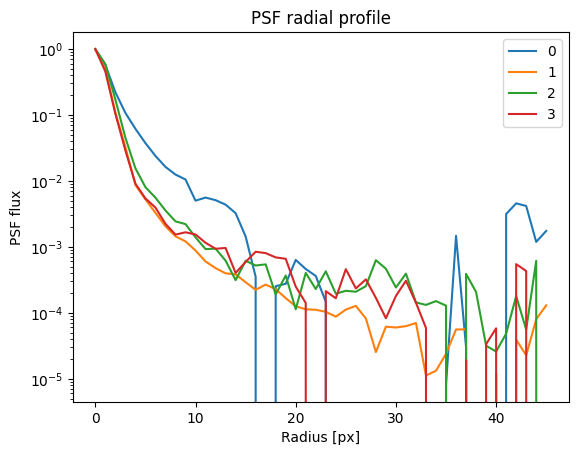

In [83]:
for i,n in zip(stars_data,added_index):
    psf = i  # or whichever band
    #psf = full_psf
    cy, cx = np.array(psf.shape) // 2
    y, x = np.indices(psf.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    radial_profile = np.bincount(r.ravel(), psf.ravel()) / np.bincount(r.ravel())
    plt.semilogy(radial_profile,label=n)
plt.xlabel("Radius [px]"); plt.ylabel("PSF flux"); plt.title("PSF radial profile")
plt.legend()
plt.show()

In [84]:
result = build_psf_edit(stars_data, np.sqrt(stars_sigma_2), subsampling_factor=2, 
                        field_distortion=False, stamp_coordinates=None,masks=masks,adjust_sky = False,
                        regularization_strength_scales=3, regularization_strength_hf=3, regularization_strength_positivity=1000)

/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)
optax.adabelief: 100%|██████████| 2000/2000 [00:08<00:00, 228.98it/s]


In [85]:
#model_no_distortion = result['k']
narrow_psfs = result["narrow_psf"]
full_psf = result["full_psf"]

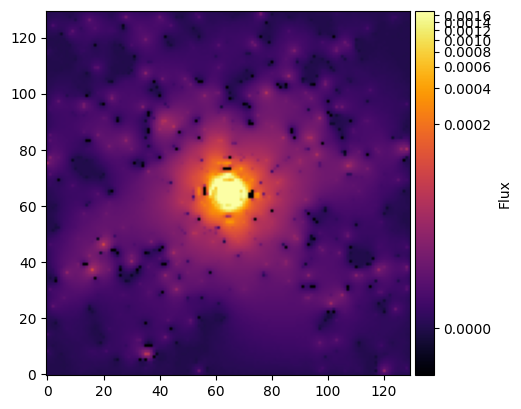

In [86]:
nice_psf_plot(narrow_psfs)

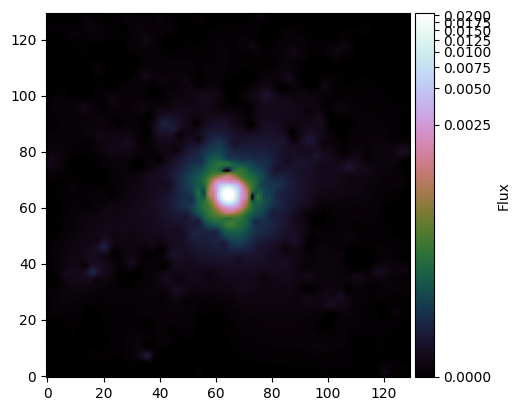

In [87]:
nice_psf_plot(full_psf,percent=99.9,cmap="cubehelix")

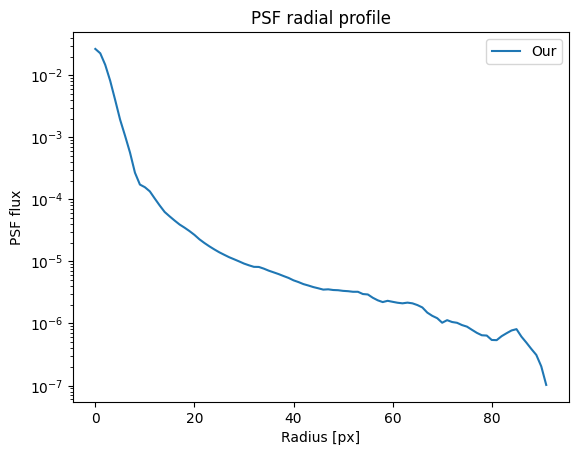

In [88]:
# Radial profile of your PSF
psf = full_psf  # or whichever band
#psf = full_psf
cy, cx = np.array(psf.shape) // 2
y, x = np.indices(psf.shape)
r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
radial_profile = np.bincount(r.ravel(), psf.ravel()) / np.bincount(r.ravel())
plt.semilogy(radial_profile,label="Our")
#plt.ylim(1e-7)
plt.xlabel("Radius [px]"); plt.ylabel("PSF flux"); plt.title("PSF radial profile")
plt.legend()

In [89]:
save_npy(narrow_psfs,'data_for_starred/narrow_psfs.npy')

Saved npy to: data_for_starred/narrow_psfs.npy
